# *Week 6: Advanced Preprocessing & CNNs *


|*Name:*        | Rubab Qaiser                                       |
|---------------|----------------------------------------------------|
|*Course:*      | Introduction to the Applied Artificial Intelligence|
|*Semester:*    | BS 8th Semester                                    |
|*Week:*        | Weed 5                                             |
|*Project:*     | Image Preprocessing + Convolutionl Neural Networks |
|*Lab Duration:*| 90 minutes                                         |

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rubabq66/receiptdataset/receipt_dataset_1000/dataset_metadata.json
/kaggle/input/datasets/rubabq66/receiptdataset/receipt_dataset_1000/boxes/PKR-00157.box
/kaggle/input/datasets/rubabq66/receiptdataset/receipt_dataset_1000/boxes/PKR-00740.box
/kaggle/input/datasets/rubabq66/receiptdataset/receipt_dataset_1000/boxes/PKR-00061.box
/kaggle/input/datasets/rubabq66/receiptdataset/receipt_dataset_1000/boxes/PKR-00056.box
/kaggle/input/datasets/rubabq66/receiptdataset/receipt_dataset_1000/boxes/PKR-00224.box
/kaggle/input/datasets/rubabq66/receiptdataset/receipt_dataset_1000/boxes/PKR-00217.box
/kaggle/input/datasets/rubabq66/receiptdataset/receipt_dataset_1000/boxes/PKR-00672.box
/kaggle/input/datasets/rubabq66/receiptdataset/receipt_dataset_1000/boxes/PKR-00171.box
/kaggle/input/datasets/rubabq66/receiptdataset/receipt_dataset_1000/boxes/PKR-00982.box
/kaggle/input/datasets/rubabq66/receiptdataset/receipt_dataset_1000/boxes/PKR-00954.box
/kaggle/input/datasets/rubabq6

## *Lab Overview*
1. Apply prespective correction to straighten skewed documents
2. Implementing automatic deskewing algoritms
3. Uing morphological operations of noise reduction
4. Build and train a CNN for digit recognition
   

In [2]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install imutils

Note: you may need to restart the kernel to use updated packages.


### *PART 1:Advanced Preprocessing*

### *Task 1.1: Persspective Correction*

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def order_points(pts):
    rect=np.zeros((4,2),dtype='float32')
    s=pts.sum(axis=1)
    rect[0]=pts[np.argmin(s)] #top-left
    rect[2]=pts[np.argmax(s)] #bottom-right
    diff=np.diff(pts,axis=1)
    rect[3]=pts[np.argmax(diff)] #bottom-left
    rect[1]=pts[np.argmin(diff)] #top-right
    return rect

def four_point_transform(image,pts):
    rect=order_points(pts)
    (t1,tr,br,b1)=rect
    widthA=np.linalg.norm(br-b1)
    widthB=np.linalg.norm(tr-t1)
    mmaxWidth=max(int(widthA),int(widthB))
    heightA=np.linalg.norm(tr-br)
    heightB=np.linalg.norm(t1-b1)
    maxHeight=max(int(heightA),int(heightB))
    #destination points
    dst=np.array([ 
        [0,0], 
        [maxWidth - 1,0],
        [maxWidth-1,maxHeight-1],
        [0,maxHeight-1]
    ],dtype='flot32')
    #perspective transform
    M=cv2.getPerspectiveTransform(rect,dst)
    warped=cv2.wrapPerspective(image,M,(maxWidth,maxHeight))
    return wraped

### *Task 1.2: Automatic Deskewing*

In [5]:
def deskew(image):
    gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    gray=cv2.bitwise_not(gray) #invert colors
    thresh=cv2.threshold(gray,0,255,cv2.THRESH_BINAR | cv2.THRESH_OTSU)[1]
    #find coordinates of all non-zero pixels
    coords=np.column_stack(np.where(thresh>0))
    #adjust angle
    if angle<-45:
        angle=cv2.minAreaRect(coords)[-1]
    else:
        angle=-angle
        
    (h,w)=image.shape[:2]
    center=(w//2,h//2)
    M=cv2.getRotationMatrix2D(center,angle,1.0)
    rotated=cv2.wrafAffine(image,M,(w,h),flags=cv2.INTER_CUBIC,borderMode=cv2.BORDER_REPLICATE)
    return rotated,angle
        

### *Task 1.3: Morphological Operations

In [9]:
import cv2
import os

image_path = 'PKR-00001.png'

if not os.path.exists(image_path):
    print(f"File not found: {image_path}")
else:
    img = cv2.imread(image_path)

    if img is None:
        print("Image could not be loaded.")
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        print("Image loaded successfully!")

File not found: PKR-00001.png


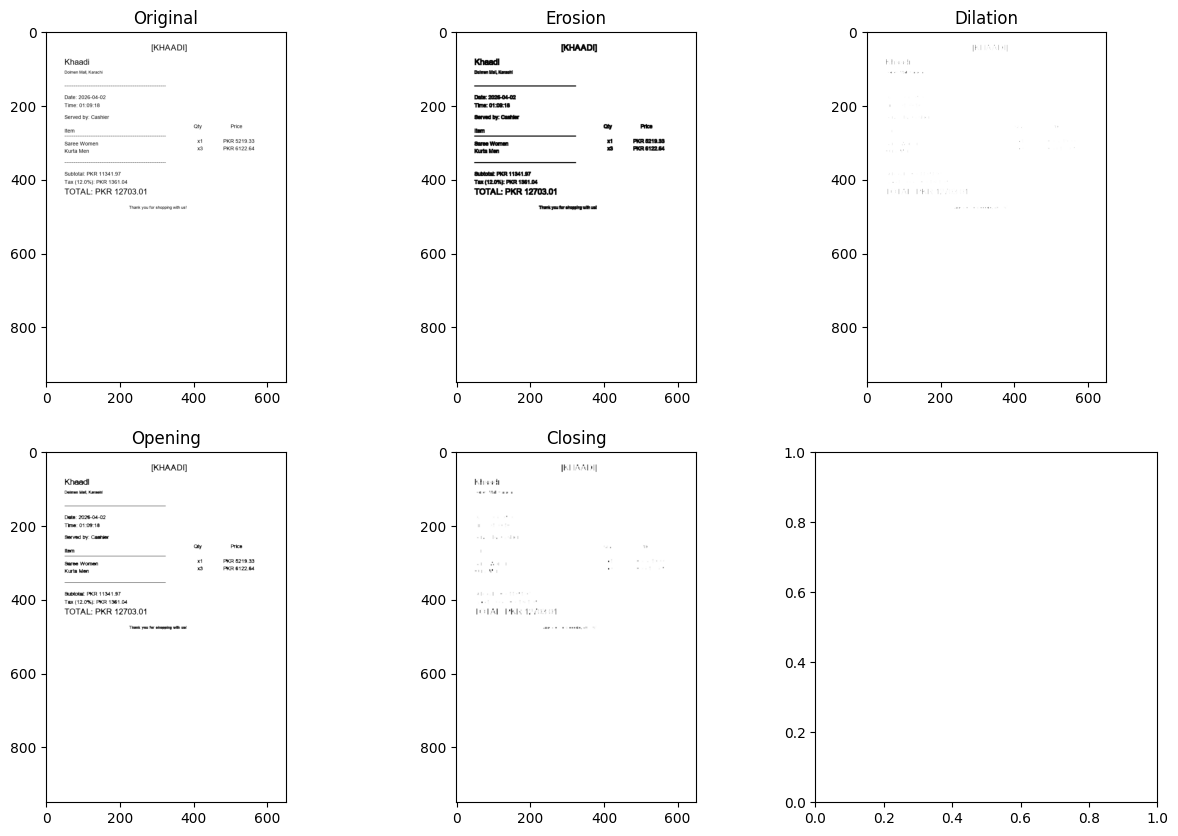

In [13]:
image_path='/kaggle/input/datasets/rubabq66/receiptdataset/receipt_dataset_1000/images/PKR-00001.png'
img=cv2.imread(image_path)
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
kernel=np.ones((3,3),np.uint8)
#Erosion-remove noise 
erosion=cv2.erode(gray,kernel,iterations=1)
#Dilation-fill gaps
dilation=cv2.dilate(gray,kernel,iterations=1)
#Opening- remove small noise
opening=cv2.morphologyEx(gray,cv2.MORPH_OPEN,kernel)
#closing- remove small noise
closing=cv2.morphologyEx(gray,cv2.MORPH_CLOSE,kernel)
#Display all results
fig,axes=plt.subplots(2,3,figsize=(15,10))
axes[0,0].imshow(gray,cmap='gray')
axes[0,0].set_title('Original')

axes[0,1].imshow(erosion,cmap='gray')
axes[0,1].set_title('Erosion')

axes[0,2].imshow(dilation,cmap='gray')
axes[0,2].set_title('Dilation')

axes[1,0].imshow(opening,cmap='gray')
axes[1,0].set_title('Opening')

axes[1,1].imshow(closing,cmap='gray')
axes[1,1].set_title('Closing')

plt.show()


## *PART 2: Build CNN From Scratch*

### *Task 2.1: LOAD MNIST*

In [14]:
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models
(x_train,y_train), (x_test,y_test)= mnist.load_data()
print(f' Train samples: {x_train.shape[0]}')
print(f' Test samples: {x_test.shape[0]}')
print(f' Image shape: {x_train.shape[1:]}')


2026-04-26 07:08:49.713760: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777187329.906536      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777187329.964648      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777187330.444795      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777187330.444831      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777187330.444834      55 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Train samples: 60000
 Test samples: 10000
 Image shape: (28, 28)


### *Task 2.2: Preprocess Data*

In [16]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255
y_train=keras.utils.to_categorical(y_train,10)
y_test=keras.utils.to_categorical(y_test,10)

### *Task 2.3: Build CNN Architecture*

In [23]:
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')
    
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,034 (28.20 MB)

 Trainable params: 7,393,034 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

### *Task 2.4: Train the model*

In [25]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

In [26]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/10


I0000 00:00:1777188949.106465     248 service.cc:152] XLA service 0x7a4be400a4c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777188949.106499     248 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777188949.106502     248 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777188949.429898     248 cuda_dnn.cc:529] Loaded cuDNN version 91002


 42/422 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4817 - loss: 1.6432

I0000 00:00:1777188952.315701     248 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8245 - loss: 0.5688 - val_accuracy: 0.9835 - val_loss: 0.0608
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9729 - loss: 0.0864 - val_accuracy: 0.9882 - val_loss: 0.0443
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9821 - loss: 0.0576 - val_accuracy: 0.9898 - val_loss: 0.0383
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9861 - loss: 0.0447 - val_accuracy: 0.9893 - val_loss: 0.0367
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9902 - loss: 0.0342 - val_accuracy: 0.9905 - val_loss: 0.0333
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9908 - loss: 0.0298 - val_accuracy: 0.9900 - val_loss: 0.0347
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9925 - loss: 0.0240 - val_accuracy: 0.9915 - val_loss: 0.0335
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9921 - loss: 0.0231 - val_accuracy: 0.9923 - val

##  Image Processing & Digit Recognition Pipeline — Summary

This notebook demonstrates a complete pipeline combining **classical image processing** (using OpenCV and NumPy) with **deep learning** (a CNN trained on the MNIST).

---

##  1. Perspective Transformation (Document Rectification)

* Implemented using:

  * `order_points()`
  * `four_point_transform()`

###  Key Idea:

* Detects 4 corner points of a skewed object (e.g., document)
* Reorders them into a consistent format:

  ```
  [top-left, top-right, bottom-right, bottom-left]
  ```
* Applies a **perspective transform** to convert the tilted view into a **straight rectangular (bird’s-eye) view**

###  Outcome:

* Converts angled images into clean, aligned documents
* Forms the **first step of a document scanner system**

---

##  2. Image Deskewing (Rotation Correction)

* Implemented using:

  * `deskew(image)`

###  Key Idea:

* Converts image → grayscale → binary
* Extracts coordinates of foreground pixels
* Uses `minAreaRect` to estimate rotation angle
* Rotates image to correct tilt

###  Outcome:

* Automatically straightens rotated images
* Improves readability and preprocessing for OCR/ML models

---

##  3. Morphological Image Processing

* Operations applied:

  * **Erosion**
  * **Dilation**
  * **Opening**
  * **Closing**

###  Key Idea:

Using a kernel (3×3 matrix) to refine image structure:

| Operation | Purpose                               |
| --------- | ------------------------------------- |
| Erosion   | Removes small noise (shrinks objects) |
| Dilation  | Expands objects, fills gaps           |
| Opening   | Removes small white noise             |
| Closing   | Fills small holes                     |

###  Outcome:

* Cleans noisy images
* Enhances feature quality before feeding into models

---

##  4. Visualization

* Used Matplotlib to:

  * Display original and processed images
  * Compare effects of different operations side-by-side

---

##  5. CNN Model for Digit Recognition (MNIST)

* Trained a **Convolutional Neural Network (CNN)** on the MNIST

###  Key Idea:

* Input: 28×28 grayscale digit images
* CNN learns:

  * Edges → shapes → digit patterns
* Outputs predicted digit (0–9)

###  Outcome:

* Accurate handwritten digit classification
* Demonstrates integration of **image preprocessing + deep learning**

---

##  Overall System Understanding

This project combines:

1. **Geometric correction**

   * Perspective transform
   * Deskewing

2. **Image enhancement**

   * Morphological operations

3. **Intelligent recognition**

   * CNN (MNIST classifier)

---

##  Big Picture



```
Raw Image
   ↓
Perspective Fix
   ↓
Deskewing
   ↓
Noise Removal
   ↓
CNN Classification
   ↓
Final Output
```

---

##  Applications

* Document scanners (CamScanner-like apps)
* OCR preprocessing systems
* Automated form digit recognition
* Bank cheque / handwritten digit detection

---

